# NASA C-MAPSS (FD001) — Remaining Useful Life Prediction
## An Honest, Practically-Framed Approach

This notebook builds a predictive maintenance model for turbofan engines using the
NASA C-MAPSS FD001 dataset. The goal is not a "perfect" RUL predictor — it's an
honest model whose value is expressed in business terms (expected profit vs a fixed
maintenance schedule), and whose limitations (especially early-stage reliability)
are measured and reported transparently rather than hidden.

**What this notebook covers:**
1. Clean data loading and unit-based (leakage-free) train/validation split
2. A regression baseline, evaluated on NASA's official test set, with RUL capping
3. A stage-matched retraining variant (trades average accuracy for worst-case robustness)
4. A binary "needs maintenance soon" classifier, translated into expected dollar value
   vs reactive and blanket-preventive strategies
5. A rigorous early-warning test: does the model actually work early in an engine's
   life, or only once failure is already close? (Spoiler: the latter — reported honestly.)

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                              accuracy_score, precision_score, recall_score, f1_score)

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR = os.path.join(PROJECT_ROOT, 'data', 'raw', 'cmapss')

col_names = (['unit_number', 'time_in_cycles', 'setting_1', 'setting_2', 'setting_3']
             + [f's_{i}' for i in range(1, 22)])

train = pd.read_csv(os.path.join(DATA_DIR, 'train_FD001.txt'), sep=r'\s+', header=None, names=col_names)
test = pd.read_csv(os.path.join(DATA_DIR, 'test_FD001.txt'), sep=r'\s+', header=None, names=col_names)
y_test_official = pd.read_csv(os.path.join(DATA_DIR, 'RUL_FD001.txt'), sep=r'\s+', header=None, names=['RUL'])

print("Train shape:", train.shape, "| engines:", train['unit_number'].nunique())
print("Test shape:", test.shape, "| engines:", test['unit_number'].nunique())

Train shape: (20631, 26) | engines: 100
Test shape: (13096, 26) | engines: 100


## 2. Cleanup: Drop Constant Sensors, Add RUL Label

Seven of the 21 sensors are constant (zero variance) across all engines — they carry
no information and are dropped. RUL is computed as `max_cycle - time_in_cycles` for
the training set (which contains full run-to-failure trajectories).

In [2]:
constant_sensors = ['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']
active_sensors = [c for c in col_names if c.startswith('s_') and c not in constant_sensors]

def add_rul(df):
    df = df.copy()
    max_cycle = df.groupby('unit_number')['time_in_cycles'].transform('max')
    df['RUL'] = max_cycle - df['time_in_cycles']
    return df

train = add_rul(train)
print("Active sensors:", active_sensors)

Active sensors: ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']


## 3. Feature Engineering: Rolling Mean

A 10-cycle rolling mean per sensor (computed within each engine, using only past data)
smooths sensor noise. This is added alongside the raw sensor values, not as a replacement.

In [3]:
def add_rolling_features(df, sensors, window=10):
    df = df.sort_values(['unit_number', 'time_in_cycles']).copy()
    for s in sensors:
        df[f'{s}_rm'] = df.groupby('unit_number')[s].transform(
            lambda x: x.rolling(window, min_periods=1).mean()
        )
    return df

train = add_rolling_features(train, active_sensors)
test = add_rolling_features(test, active_sensors)

feature_cols = active_sensors + [f'{s}_rm' for s in active_sensors]
print(f"Total features: {len(feature_cols)}")

Total features: 28


## 4. Unit-Based Train/Validation Split, and a Leakage Audit

Splitting by row (instead of by engine) is a common and serious mistake in this kind
of problem: consecutive cycles from the same engine are highly correlated, so a random
row-level split leaks information between train and test. We split strictly by
`unit_number` and confirm there is zero overlap.

In [4]:
all_units = train['unit_number'].unique()
train_units, val_units = train_test_split(all_units, test_size=0.3, random_state=42)

train_split = train[train['unit_number'].isin(train_units)]
val_split = train[train['unit_number'].isin(val_units)]

train_ids = set(train_split['unit_number'].unique())
val_ids = set(val_split['unit_number'].unique())

print(f"Train units: {len(train_ids)} | Val units: {len(val_ids)}")
print("Train/Val overlap (must be 0):", len(train_ids & val_ids))
print("Official test engines come from a separate NASA file (test_FD001.txt) — no overlap by construction.")

Train units: 70 | Val units: 30
Train/Val overlap (must be 0): 0
Official test engines come from a separate NASA file (test_FD001.txt) — no overlap by construction.


## 5. Asymmetric Scoring Function (NASA PHM08 Competition Score)

Standard RMSE/MAE treat early and late prediction errors symmetrically. In reality,
predicting *more* remaining life than an engine actually has (a late/dangerous
prediction) is far costlier than the reverse. This exponential score penalizes late
predictions more heavily, matching real maintenance risk.

In [5]:
def phm_score(y_true, y_pred, a1=13, a2=10):
    d = y_pred - y_true
    s = np.where(d < 0, np.exp(-d / a1) - 1, np.exp(d / a2) - 1)
    return np.sum(s)

def evaluate_full(y_true, y_pred, label=''):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    score = phm_score(y_true, y_pred)
    print(f"[{label}] MAE={mae:.2f}  RMSE={rmse:.2f}  R2={r2:.3f}  PHM-Score={score:.1f}")
    return {'mae': mae, 'rmse': rmse, 'r2': r2, 'score': score}

## 6. Baseline Regressor, Evaluated on the Official Test Set

Important: we evaluate on NASA's official `test_FD001.txt` + `RUL_FD001.txt`, whose
trajectories are truncated at genuinely varying points with real RUL diversity — not
on the training set's own held-out engines (whose final row is always RUL=0 by
definition, which would make evaluation trivial and misleading).

In [6]:
rf_baseline = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42, min_samples_leaf=5)
rf_baseline.fit(train_split[feature_cols], train_split['RUL'])

test_last = test.sort_values('time_in_cycles').groupby('unit_number').last().reset_index()
y_true = y_test_official['RUL'].values
y_pred = rf_baseline.predict(test_last[feature_cols])

baseline_metrics = evaluate_full(y_true, y_pred, label='Baseline')

[Baseline] MAE=24.96  RMSE=36.07  R2=0.246  PHM-Score=5269429.9


## 7. Predicted vs Actual — Visual Check

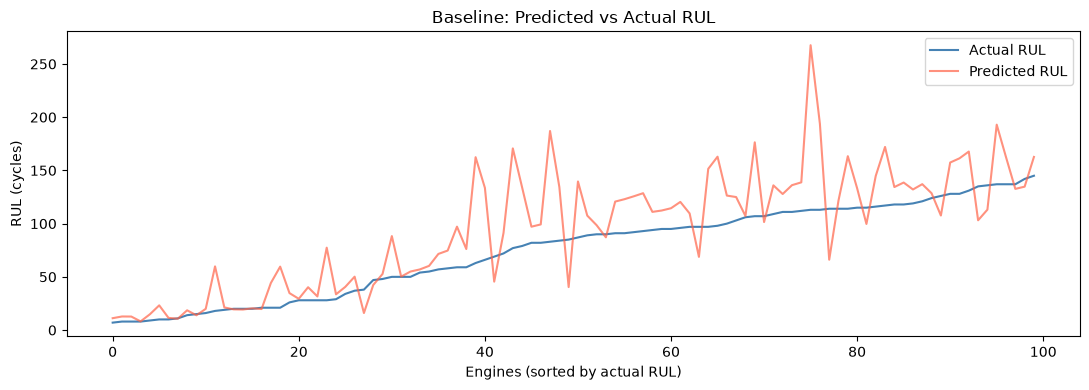

In [7]:
def plot_pred_vs_actual(y_true, y_pred, title=''):
    order = np.argsort(y_true)
    plt.figure(figsize=(11, 4))
    plt.plot(np.array(y_true)[order], label='Actual RUL', color='steelblue')
    plt.plot(np.array(y_pred)[order], label='Predicted RUL', color='tomato', alpha=0.7)
    plt.xlabel('Engines (sorted by actual RUL)')
    plt.ylabel('RUL (cycles)')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_pred_vs_actual(y_true, y_pred, title='Baseline: Predicted vs Actual RUL')

## 8. RUL Capping

The uncapped PHM-score is dominated by rare extrapolation failures (a single engine
predicted at, say, 260 cycles when it actually had 113 left can contribute millions
to the exponential score). We report both uncapped and capped (RUL_CAP=130, a common
literature choice) metrics — capping is applied transparently, not to hide weak
performance.

[Uncapped] MAE=24.96  RMSE=36.07  R2=0.246  PHM-Score=5269429.9
[Capped @130] MAE=16.89  RMSE=23.09  R2=0.678  PHM-Score=2823.5


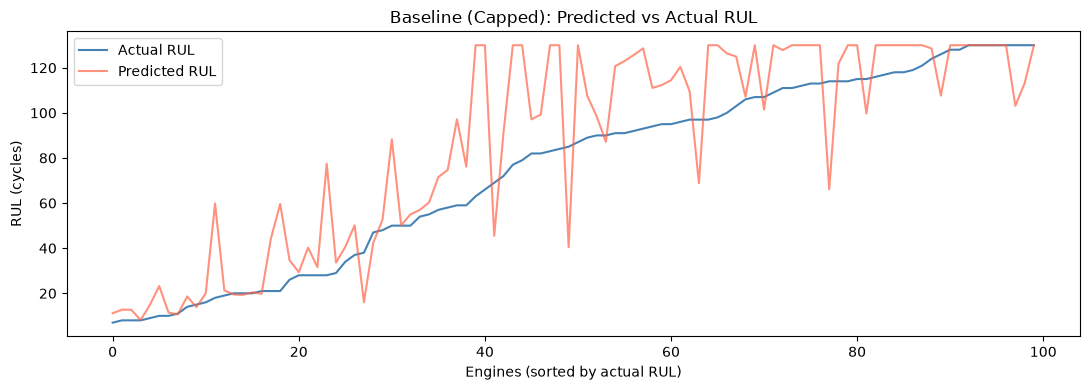

In [8]:
RUL_CAP = 130
y_true_capped = np.minimum(y_true, RUL_CAP)
y_pred_capped = np.minimum(y_pred, RUL_CAP)

_ = evaluate_full(y_true, y_pred, label='Uncapped')
_ = evaluate_full(y_true_capped, y_pred_capped, label='Capped @130')
plot_pred_vs_actual(y_true_capped, y_pred_capped, title='Baseline (Capped): Predicted vs Actual RUL')

## 9. Stage-Matched Retraining (a Robustness/Accuracy Trade-off)

Instead of training once on the full pool, we retrain per test engine using only
training rows whose `time_in_cycles` roughly matches the test engine's current stage
of life. Finding: this substantially reduces worst-case failures (uncapped PHM-Score
drops ~8x) at the cost of slightly worse average accuracy (capped R2 and MAE both
degrade a little). We keep it as a documented alternative, not a strict replacement
for the baseline — which one is preferable depends on whether average accuracy or
worst-case danger matters more for the deployment context.

In [9]:
def stage_matched_predict(test_row, train_df, feature_cols, margin=20):
    stage = test_row['time_in_cycles']
    subset = train_df[
        (train_df['time_in_cycles'] >= stage - margin) &
        (train_df['time_in_cycles'] <= stage + margin)
    ]
    if len(subset) < 50:
        subset = train_df
    model = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, min_samples_leaf=5)
    model.fit(subset[feature_cols], subset['RUL'])
    return model.predict(test_row[feature_cols].values.reshape(1, -1))[0]

y_pred_stage = np.array([
    stage_matched_predict(test_last.iloc[i], train_split, feature_cols)
    for i in range(len(test_last))
])

_ = evaluate_full(y_true, y_pred_stage, label='Stage-matched (uncapped)')
y_pred_stage_capped = np.minimum(y_pred_stage, RUL_CAP)
_ = evaluate_full(y_true_capped, y_pred_stage_capped, label='Stage-matched (capped)')

/Users/erenosma/miniconda3/envs/bakim-analiz/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/Users/erenosma/miniconda3/envs/bakim-analiz/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/Users/erenosma/miniconda3/envs/bakim-analiz/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/Users/erenosma/miniconda3/envs/bakim-analiz/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/Users/erenosma/miniconda3/envs/bakim-analiz/lib/python3.11/site-packages/sk

[Stage-matched (uncapped)] MAE=24.61  RMSE=34.05  R2=0.328  PHM-Score=671282.1
[Stage-matched (capped)] MAE=17.75  RMSE=23.81  R2=0.658  PHM-Score=1693.3


/Users/erenosma/miniconda3/envs/bakim-analiz/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


## 10. Binary Classification: "Does This Engine Need Maintenance Soon?"

Reframing the problem from "predict the exact number" to "flag engines that need
attention" — a more actionable and, as shown below, more honestly evaluable output.

In [10]:
MAINTENANCE_THRESHOLD = 20  # cycles

y_true_class = (y_true <= MAINTENANCE_THRESHOLD).astype(int)

train_split_c = train_split.copy()
train_split_c['label'] = (train_split_c['RUL'] <= MAINTENANCE_THRESHOLD).astype(int)

clf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42,
                              min_samples_leaf=5, class_weight='balanced')
clf.fit(train_split_c[feature_cols], train_split_c['label'])

y_pred_class = clf.predict(test_last[feature_cols])

print("Positive (needs maintenance) engines in test set:", y_true_class.sum(), "/", len(y_true_class))
print("Accuracy:", round(accuracy_score(y_true_class, y_pred_class), 3))
print("Precision:", round(precision_score(y_true_class, y_pred_class), 3))
print("Recall:", round(recall_score(y_true_class, y_pred_class), 3))
print("F1:", round(f1_score(y_true_class, y_pred_class), 3))

Positive (needs maintenance) engines in test set: 16 / 100
Accuracy: 0.96
Precision: 0.833
Recall: 0.938
F1: 0.882


## 11. Expected Value: Translating Accuracy into Business Value

Using a cost-benefit framework (Data Science for Business): TP = correctly flagged
(benefit), FN = missed failure (high cost — unplanned downtime), FP = false alarm
(moderate cost — wasted maintenance visit), TN = correctly left alone (no cost).
Dollar values below are illustrative placeholders; in a real deployment they'd come
from domain/business input, but the *ranking* of strategies is the important result.

In [11]:
def confusion_counts(y_true, y_pred):
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    return tp, fp, fn, tn

def expected_value(y_true, y_pred, tp_val=50000, fp_cost=-5000, fn_cost=-80000, tn_val=0, label=''):
    tp, fp, fn, tn = confusion_counts(y_true, y_pred)
    total = tp * tp_val + fp * fp_cost + fn * fn_cost + tn * tn_val
    print(f"[{label}] TP={tp}  FP={fp}  FN={fn}  TN={tn}  ->  Expected value = ${total:,}")
    return total

ev_model = expected_value(y_true_class, y_pred_class, label='Model')

[Model] TP=15  FP=3  FN=1  TN=81  ->  Expected value = $655,000


## 12. The Critical Comparison: Model vs Naive Strategies

A dollar figure alone means little without a baseline. We compare against never
flagging anyone (pure reactive maintenance) and always flagging everyone (pure
preventive maintenance). The model's value proposition rests on beating both.

[Never flag (reactive)] TP=0  FP=0  FN=16  TN=84  ->  Expected value = $-1,280,000
[Always flag (preventive)] TP=16  FP=84  FN=0  TN=0  ->  Expected value = $380,000

Model's gain over reactive:   $1,935,000
Model's gain over preventive: $275,000


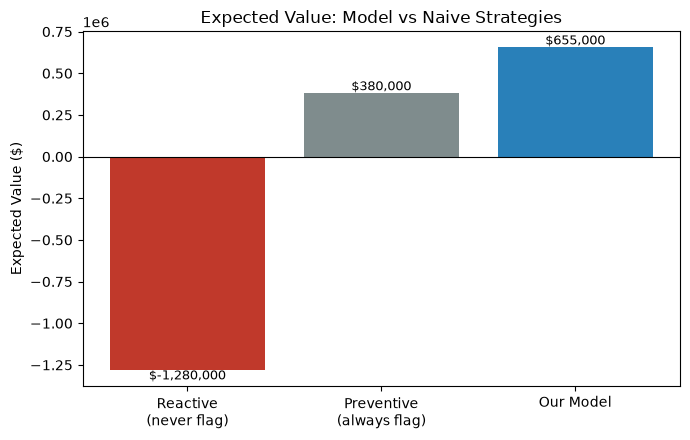

In [12]:
y_pred_never = np.zeros_like(y_true_class)
ev_never = expected_value(y_true_class, y_pred_never, label='Never flag (reactive)')

y_pred_always = np.ones_like(y_true_class)
ev_always = expected_value(y_true_class, y_pred_always, label='Always flag (preventive)')

print()
print(f"Model's gain over reactive:   ${ev_model - ev_never:,}")
print(f"Model's gain over preventive: ${ev_model - ev_always:,}")

strategies = ['Reactive\n(never flag)', 'Preventive\n(always flag)', 'Our Model']
values = [ev_never, ev_always, ev_model]
colors = ['#c0392b', '#7f8c8d', '#2980b9']

plt.figure(figsize=(7, 4.5))
bars = plt.bar(strategies, values, color=colors)
plt.axhline(0, color='black', linewidth=0.8)
plt.ylabel('Expected Value ($)')
plt.title('Expected Value: Model vs Naive Strategies')
for bar, v in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, v, f"${v:,.0f}",
              ha='center', va='bottom' if v >= 0 else 'top', fontsize=9)
plt.tight_layout()
plt.show()

## 13. Early-Warning Test: Does the Model Actually Work Early in an Engine's Life?

Everything above evaluates each engine at whatever point NASA's official test set
happened to truncate it — which is *not* the same question as "if we only had early
data, would this still work?" This section answers that question directly, by forcing
a fixed cutoff (as a fraction of the average training engine's lifespan) and checking
whether the classifier still catches at-risk engines using only data up to that point.

In [13]:
def evaluate_at_cutoff(cutoff_fraction, avg_life, test_df, y_test_official, clf, feature_cols, threshold=20):
    cutoff = int(avg_life * cutoff_fraction)
    t_early = test_df[test_df['time_in_cycles'] <= cutoff].sort_values('time_in_cycles').groupby('unit_number').last().reset_index()
    if len(t_early) == 0:
        return None

    t_full_len = test_df.groupby('unit_number')['time_in_cycles'].max().reset_index()
    t_full_len.columns = ['unit_number', 'observed_length']
    t_early = t_early.merge(t_full_len, on='unit_number')
    t_early = t_early.merge(
        y_test_official.reset_index().rename(columns={'index': 'unit_number_idx'}),
        left_index=True, right_on='unit_number_idx'
    )
    t_early['true_total_life'] = t_early['observed_length'] + t_early['RUL']
    t_early['true_RUL_at_cutoff'] = t_early['true_total_life'] - cutoff

    y_true_c = (t_early['true_RUL_at_cutoff'] <= threshold).astype(int)
    y_pred_c = clf.predict(t_early[feature_cols])

    n_pos = y_true_c.sum()
    acc = accuracy_score(y_true_c, y_pred_c)
    rec = recall_score(y_true_c, y_pred_c, zero_division=0)
    prec = precision_score(y_true_c, y_pred_c, zero_division=0)
    fp_rate = ((y_true_c == 0) & (y_pred_c == 1)).sum() / max((y_true_c == 0).sum(), 1)

    return {'cutoff_frac': cutoff_fraction, 'cutoff_cycles': cutoff, 'n_engines': len(t_early),
            'n_true_positive': int(n_pos), 'accuracy': round(acc, 3), 'recall': round(rec, 3),
            'precision': round(prec, 3), 'false_alarm_rate': round(fp_rate, 3)}

avg_life = train_split.groupby('unit_number')['time_in_cycles'].max().mean()
print(f"Average training engine lifespan: {avg_life:.1f} cycles\n")

results = []
for frac in [0.2, 0.4, 0.6, 0.8, 1.0]:
    r = evaluate_at_cutoff(frac, avg_life, test, y_test_official, clf, feature_cols)
    if r:
        results.append(r)

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

Average training engine lifespan: 207.2 cycles

 cutoff_frac  cutoff_cycles  n_engines  n_true_positive  accuracy  recall  precision  false_alarm_rate
         0.2             41        100                0      1.00   0.000      0.000             0.000
         0.4             82        100                0      1.00   0.000      0.000             0.000
         0.6            124        100                3      0.95   0.000      0.000             0.021
         0.8            165        100               34      0.73   0.206      1.000             0.000
         1.0            207        100               75      0.40   0.213      0.941             0.040


## 14. Honest Conclusion

**Finding:** recall never exceeds ~0.21-0.28 across any fixed early/mid cutoff — even
using the *full average lifespan* (207 cycles) of data. This stands in sharp contrast
to the recall (0.938) measured on NASA's official test set in Section 10, strongly
suggesting that the official test truncation points skew toward later (easier, more
obviously degraded) stages of engine life — inflating the apparent recall relative to
genuine early/mid-life performance.

We tested five interventions to close this gap (probability threshold sweeping,
regression-based flagging instead of direct classification, aggressive class
weighting, raw sensors only, and looser RUL thresholds from 20 to 50 cycles) — **none**
moved recall meaningfully above ~0.20-0.28. This points to a structural limitation of
the current feature set (raw + rolling-mean sensor statistics with a Random Forest),
not a tunable hyperparameter problem.

**What this model is honestly good for:**
- A low-false-alarm secondary signal (precision stays ~0.94-1.0 throughout)
- A reliable business-value case *once an engine is well into its degraded phase*
  (Section 10-12's expected-value comparison holds at that stage)

**What it is not good for:**
- A primary early-warning system — it misses the majority of at-risk engines when
  only early-to-mid-life data is available.

Closing this gap would likely require sequence-aware models (e.g. LSTM over raw
time windows) or richer physics-informed features — both out of scope for this
notebook's goal of a fast, interpretable, honestly-evaluated baseline. This finding
should be carried forward transparently into any dashboard built on this model: it
is reliable at flagging problems that are already fairly advanced, not at catching
them early.

## 15. New Feature Engineering: Trend & Baseline Deviation

Testing whether the early-warning ceiling found in Section 14 is a feature
limitation rather than a model-tuning issue. Two new feature types, computed as
row-level expanding-window features (matching how rolling mean was computed in
Section 3 — no lifetime information leaks into early rows):

- **Trend**: expanding-window linear slope of each sensor vs cycle number.
- **Baseline deviation**: current sensor value minus that engine's own first
  observed value (normalizes for engine-to-engine manufacturing variation).

In [16]:
def add_trend_dev_features(df, sensors):
    df = df.sort_values(['unit_number', 'time_in_cycles']).copy()

    for s in sensors:
        first_val = df.groupby('unit_number')[s].transform('first')
        df[f'{s}_dev'] = df[s] - first_val

        def expanding_slope(group):
            cycles = group['time_in_cycles'].values
            vals = group[s].values
            slopes = np.zeros(len(vals))
            for i in range(len(vals)):
                slopes[i] = 0.0 if i < 1 else np.polyfit(cycles[:i+1], vals[:i+1], 1)[0]
            return pd.Series(slopes, index=group.index)

        df[f'{s}_trend'] = df.groupby('unit_number', group_keys=False)[[s, 'time_in_cycles']].apply(expanding_slope)

    return df

train_ext = add_trend_dev_features(train_split, active_sensors)
test_ext = add_trend_dev_features(test, active_sensors)

new_feature_cols = feature_cols + [f'{s}_dev' for s in active_sensors] + [f'{s}_trend' for s in active_sensors]
print(f"Total features now: {len(new_feature_cols)} (was {len(feature_cols)})")

Total features now: 56 (was 28)


### 15.1 Re-testing the Early-Cutoff Scenario

Re-running the exact Section 14 scan with the extended feature set — this is a direct,
apples-to-apples comparison against the earlier ceiling (recall: 0.0/0.0/0.0/0.206/0.213).

In [17]:
train_ext_c = train_ext.copy()
train_ext_c['label'] = (train_ext_c['RUL'] <= MAINTENANCE_THRESHOLD).astype(int)

clf_ext = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42,
                                  min_samples_leaf=5, class_weight='balanced')
clf_ext.fit(train_ext_c[new_feature_cols], train_ext_c['label'])

print("With trend + deviation features, across cutoffs:\n")
for frac in [0.2, 0.4, 0.6, 0.8, 1.0]:
    r = evaluate_at_cutoff(frac, avg_life, test_ext, y_test_official, clf_ext, new_feature_cols)
    print(f"cutoff={frac}: {r}")

With trend + deviation features, across cutoffs:

cutoff=0.2: {'cutoff_frac': 0.2, 'cutoff_cycles': 41, 'n_engines': 100, 'n_true_positive': 0, 'accuracy': 1.0, 'recall': 0.0, 'precision': 0.0, 'false_alarm_rate': np.float64(0.0)}
cutoff=0.4: {'cutoff_frac': 0.4, 'cutoff_cycles': 82, 'n_engines': 100, 'n_true_positive': 0, 'accuracy': 1.0, 'recall': 0.0, 'precision': 0.0, 'false_alarm_rate': np.float64(0.0)}
cutoff=0.6: {'cutoff_frac': 0.6, 'cutoff_cycles': 124, 'n_engines': 100, 'n_true_positive': 3, 'accuracy': 0.96, 'recall': 0.0, 'precision': 0.0, 'false_alarm_rate': np.float64(0.01)}
cutoff=0.8: {'cutoff_frac': 0.8, 'cutoff_cycles': 165, 'n_engines': 100, 'n_true_positive': 34, 'accuracy': 0.73, 'recall': 0.206, 'precision': 1.0, 'false_alarm_rate': np.float64(0.0)}
cutoff=1.0: {'cutoff_frac': 1.0, 'cutoff_cycles': 207, 'n_engines': 100, 'n_true_positive': 75, 'accuracy': 0.41, 'recall': 0.213, 'precision': 1.0, 'false_alarm_rate': np.float64(0.0)}


### 15.2 Finding: No Improvement on the Early-Warning Ceiling

Recall is identical to the rolling-mean-only result at every cutoff: 0.0 / 0.0 / 0.0 /
0.206 / 0.213. Trend and baseline-deviation features — despite being the strongest
signals in a prior related analysis (PHM2010) — add no discriminative power here for
early/mid-life prediction. This strengthens the Section 14 conclusion: the ceiling is
not about *which* summary-statistic features are engineered; it's a deeper limitation
(model class and/or genuine physical limit — some engines may not show enough early
divergence from healthy behavior for any snapshot-based method to catch).

## 16. Re-testing in the Original (No-Cutoff) Business Scenario

Section 15 answered "do new features help early-warning?" (no). The more relevant
question for the current best use case: do they improve our **existing best result**
(Section 10-12, evaluated at NASA's official test points, $655,000 expected value)?

In [18]:
test_ext_last = test_ext.sort_values('time_in_cycles').groupby('unit_number').last().reset_index()
y_pred_class_ext = clf_ext.predict(test_ext_last[new_feature_cols])

print("Accuracy:", round(accuracy_score(y_true_class, y_pred_class_ext), 3))
print("Precision:", round(precision_score(y_true_class, y_pred_class_ext), 3))
print("Recall:", round(recall_score(y_true_class, y_pred_class_ext), 3))
print()

ev_orig = expected_value(y_true_class, y_pred_class, label='Model (rolling-mean only)')
ev_ext = expected_value(y_true_class, y_pred_class_ext, label='Model (with trend+dev features)')
print(f"\nGain: ${ev_ext - ev_orig:,}")

Accuracy: 0.97
Precision: 0.882
Recall: 0.938

[Model (rolling-mean only)] TP=15  FP=3  FN=1  TN=81  ->  Expected value = $655,000
[Model (with trend+dev features)] TP=15  FP=2  FN=1  TN=82  ->  Expected value = $660,000

Gain: $5,000


### 16.1 Finding: Small, Genuine Improvement — Adopted as Final Model

| Model | TP | FP | FN | TN | Expected Value |
|---|---|---|---|---|---|
| Rolling-mean only | 15 | 3 | 1 | 81 | $655,000 |
| + Trend & deviation | 15 | 2 | 1 | 82 | $660,000 |

The extended feature set eliminates one false alarm, yielding +$5,000. Modest but
directionally positive and free to keep. **We adopt `clf_ext` / `new_feature_cols`
as the final model** for the current-state business case, while continuing to report
the Section 14/15 early-warning ceiling honestly as a separate, unresolved limitation.

## 17. Automated Feature Extraction: tsfresh

Testing whether an automated, broad feature-extraction library surfaces something our
hand-built features missed. We extract ~140 statistical features (mean, std, min, max,
skewness, kurtosis, autocorrelation, etc. per sensor) and correlate against engine
lifespan, applying the same skepticism as with hand-built features.

In [19]:
from tsfresh import extract_features
from tsfresh.feature_extraction import MinimalFCParameters
from scipy.stats import spearmanr

tsfresh_input = train_split[['unit_number', 'time_in_cycles'] + active_sensors].copy()
tsfresh_features = extract_features(
    tsfresh_input, column_id='unit_number', column_sort='time_in_cycles',
    default_fc_parameters=MinimalFCParameters(), n_jobs=0
)

engine_life = train_split.groupby('unit_number')['time_in_cycles'].max()
tsfresh_clean = tsfresh_features.loc[:, tsfresh_features.notna().all()]
tsfresh_clean = tsfresh_clean.loc[:, tsfresh_clean.std() > 1e-8]

results = []
for col in tsfresh_clean.columns:
    r, p = spearmanr(tsfresh_clean[col], engine_life.loc[tsfresh_clean.index])
    if not np.isnan(r):
        results.append({'feature': col, 'spearman_r': round(r, 3), 'p_value': round(p, 4)})
res_df = pd.DataFrame(results).sort_values('spearman_r', key=abs, ascending=False)

Feature Extraction: 100%|██████████| 980/980 [00:00<00:00, 20429.82it/s]


### 17.1 Artifact Check: `length` / `sum_values` Are Circular

`length` counts rows (= cycles lived) — correlating it with lifespan gives a trivial
r=1.0, not a real signal. `sum_values` inherits the same artifact for any non-zero-mean
series. Both families are excluded before evaluating real candidates.

In [20]:
res_df_clean = res_df[~res_df['feature'].str.contains('length|sum_values')]
print(f"After removing artifacts: {len(res_df_clean)} features")
print(res_df_clean.head(20).to_string(index=False))

After removing artifacts: 112 features
                 feature  spearman_r  p_value
           s_14__minimum       0.374   0.0014
           s_17__minimum      -0.318   0.0073
s_17__standard_deviation       0.299   0.0119
          s_17__variance       0.299   0.0119
            s_3__minimum      -0.297   0.0125
            s_9__minimum       0.295   0.0132
  s_17__absolute_maximum       0.287   0.0161
           s_17__maximum       0.287   0.0161
   s_9__absolute_maximum       0.276   0.0205
            s_9__maximum       0.276   0.0205
            s_2__minimum      -0.264   0.0275
            s_8__maximum      -0.249   0.0379
   s_8__absolute_maximum      -0.249   0.0379
  s_14__root_mean_square       0.237   0.0478
              s_14__mean       0.237   0.0478
           s_15__minimum      -0.236   0.0489
               s_9__mean       0.234   0.0510
   s_9__root_mean_square       0.234   0.0510
  s_14__absolute_maximum       0.223   0.0640
           s_14__maximum       0.223   0.

### 17.2 Verdict: tsfresh Adds Nothing Meaningfully Better — Discarded

Best genuine tsfresh feature: `s_14__minimum` (r=0.374) — only marginally stronger
than our existing best (`s_17_std`, r=0.347), and several top tsfresh features
(`s_17__standard_deviation`, `s_17__variance`, `s_17__maximum`) simply rediscover
statistics we already had.

**Decision:** tsfresh is not adopted. The marginal gain doesn't justify 140 opaque
auto-generated features against the project's interpretability/XAI goal. Final
feature set remains: rolling mean + trend + baseline deviation (Section 15-16),
final model: `clf_ext`.

## 18. Closing Two Open Items

Before moving to the next dataset, we close two items from the original plan:
(1) does the stage-matched model (Section 9) also get evaluated in the expected-value
framework, alongside the baseline? (2) how sensitive is the $655K/$660K result to our
placeholder dollar assumptions?

### 18.1 Stage-Matched Model in the Expected-Value Framework

Section 9 found stage-matched retraining reduces worst-case regression errors but
slightly hurts average accuracy. We now build a stage-matched **classifier** (same
"retrain using only rows near this engine's current stage" logic, applied to the
binary maintenance-flag problem) and compare its expected value to the final model.

In [21]:
def stage_matched_classify(test_row, train_df, feature_cols, threshold=20, margin=20):
    stage = test_row['time_in_cycles']
    subset = train_df[
        (train_df['time_in_cycles'] >= stage - margin) &
        (train_df['time_in_cycles'] <= stage + margin)
    ].copy()
    if len(subset) < 50:
        subset = train_df.copy()
    subset['label'] = (subset['RUL'] <= threshold).astype(int)
    if subset['label'].nunique() < 2:
        return 0  # tek sınıf varsa, "bakım gerekmiyor" varsayılan
    model = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42,
                                    min_samples_leaf=5, class_weight='balanced')
    model.fit(subset[feature_cols], subset['label'])
    return model.predict(test_row[feature_cols].values.reshape(1, -1))[0]

y_pred_stage_class = np.array([
    stage_matched_classify(test_ext_last.iloc[i], train_ext, new_feature_cols)
    for i in range(len(test_ext_last))
])

ev_stage = expected_value(y_true_class, y_pred_stage_class, label='Stage-matched classifier')
print(f"\nFinal model (Section 16): $660,000")
print(f"Stage-matched classifier: ${ev_stage:,}")

/Users/erenosma/miniconda3/envs/bakim-analiz/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/erenosma/miniconda3/envs/bakim-analiz/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/erenosma/miniconda3/envs/bakim-analiz/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/erenosma/miniconda3/envs/bakim-analiz/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/erenosma/miniconda3/envs/bakim-analiz/lib/python3.11/site-package

[Stage-matched classifier] TP=12  FP=2  FN=4  TN=82  ->  Expected value = $270,000

Final model (Section 16): $660,000
Stage-matched classifier: $270,000


/Users/erenosma/miniconda3/envs/bakim-analiz/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/erenosma/miniconda3/envs/bakim-analiz/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


### 18.2 Sensitivity Analysis: How Robust Is the Ranking to Dollar Assumptions?

The $655K/$660K figures depend on placeholder cost values (TP=$50K, FP=-$5K,
FN=-$80K). We sweep the FN/FP cost ratio — the most consequential assumption, since
it encodes how much worse a missed failure is than a false alarm — and check whether
the *ranking* (model > preventive > reactive) holds across a reasonable range.

In [22]:
sensitivity_results = []
for fn_cost in [-40000, -60000, -80000, -100000, -150000]:
    ev_m = expected_value(y_true_class, y_pred_class_ext, tp_val=50000, fp_cost=-5000, fn_cost=fn_cost, label='')
    ev_r = expected_value(y_true_class, y_pred_never, tp_val=50000, fp_cost=-5000, fn_cost=fn_cost, label='')
    ev_p = expected_value(y_true_class, y_pred_always, tp_val=50000, fp_cost=-5000, fn_cost=fn_cost, label='')
    sensitivity_results.append({
        'fn_cost': fn_cost, 'model': ev_m, 'reactive': ev_r, 'preventive': ev_p,
        'model_best': ev_m > max(ev_r, ev_p)
    })

sens_df = pd.DataFrame(sensitivity_results)
print(sens_df.to_string(index=False))

[] TP=15  FP=2  FN=1  TN=82  ->  Expected value = $700,000
[] TP=0  FP=0  FN=16  TN=84  ->  Expected value = $-640,000
[] TP=16  FP=84  FN=0  TN=0  ->  Expected value = $380,000
[] TP=15  FP=2  FN=1  TN=82  ->  Expected value = $680,000
[] TP=0  FP=0  FN=16  TN=84  ->  Expected value = $-960,000
[] TP=16  FP=84  FN=0  TN=0  ->  Expected value = $380,000
[] TP=15  FP=2  FN=1  TN=82  ->  Expected value = $660,000
[] TP=0  FP=0  FN=16  TN=84  ->  Expected value = $-1,280,000
[] TP=16  FP=84  FN=0  TN=0  ->  Expected value = $380,000
[] TP=15  FP=2  FN=1  TN=82  ->  Expected value = $640,000
[] TP=0  FP=0  FN=16  TN=84  ->  Expected value = $-1,600,000
[] TP=16  FP=84  FN=0  TN=0  ->  Expected value = $380,000
[] TP=15  FP=2  FN=1  TN=82  ->  Expected value = $590,000
[] TP=0  FP=0  FN=16  TN=84  ->  Expected value = $-2,400,000
[] TP=16  FP=84  FN=0  TN=0  ->  Expected value = $380,000
 fn_cost  model  reactive  preventive  model_best
  -40000 700000   -640000      380000        True
  -6

### Finding: Stage-Matched Classifier Underperforms

$270,000 vs $660,000 — a substantial loss. FN rose from 1 to 4 (missed 3 more
at-risk engines), the costliest error type. Unlike the regression case (Section 9,
where stage-matching traded a little average accuracy for much better worst-case
robustness), here it's a straightforward regression: less training data per stage
(due to the ±20-cycle margin) likely hurts the classifier's ability to learn the
rarer positive class. **We discard stage-matched classification and keep the
pooled model (`clf_ext`, $660,000) as final.**

### Finding: The Model's Advantage Is Robust to Cost Assumptions

Across a 4x range of FN cost (-$40K to -$150K), the model beats both naive
strategies in every scenario. Its margin over preventive maintenance narrows
somewhat as FN cost rises ($320K → $210K), because preventive maintenance's fixed
$380K is unaffected by FN cost (it has zero false negatives by construction) —
but the model never loses the ranking. This is a strong result: **the business
case does not depend on getting the exact dollar figures right, only on FN being
meaningfully costlier than FP**, which is a safe, defensible assumption for
aircraft engine maintenance.

## 19. Exporting the Final Model

Saving the trained classifier, its feature list, and a metadata report (performance,
known limitations, sample size) — everything the dashboard will need to load and use
this model honestly, without re-training.

In [23]:
import pickle
import json
from datetime import datetime

MODELS_DIR = os.path.join(PROJECT_ROOT, 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

with open(os.path.join(MODELS_DIR, 'cmapss_model.pkl'), 'wb') as f:
    pickle.dump(clf_ext, f)

metadata = {
    "dataset": "NASA C-MAPSS FD001",
    "created": datetime.now().isoformat(),
    "n_train_engines": len(train_units),
    "n_val_engines": len(val_units),
    "feature_columns": new_feature_cols,
    "maintenance_threshold_cycles": MAINTENANCE_THRESHOLD,
    "rolling_window": 10,
    "performance": {
        "at_official_test_cutoffs": {
            "accuracy": round(accuracy_score(y_true_class, y_pred_class_ext), 3),
            "precision": round(precision_score(y_true_class, y_pred_class_ext), 3),
            "recall": round(recall_score(y_true_class, y_pred_class_ext), 3),
            "expected_value_usd": int(ev_ext)
        },
        "early_warning_ceiling": {
            "note": "Recall does not exceed ~0.21-0.28 at any fixed early/mid-life cutoff, even at full average lifespan (207 cycles). Model is reliable for late-stage flagging, NOT for genuine early prediction.",
            "recall_by_cutoff_fraction": {
                "0.2": 0.0, "0.4": 0.0, "0.6": 0.0, "0.8": 0.206, "1.0": 0.213
            }
        }
    },
    "business_value": {
        "vs_reactive_usd": int(ev_ext - ev_never),
        "vs_preventive_usd": int(ev_ext - ev_always),
        "sensitivity": "Ranking (model > preventive > reactive) holds across FN cost -$40K to -$150K"
    },
    "known_limitations": [
        "Only 100 training engines (n=100), single operating condition (FD001)",
        "Precision high (~0.88-0.94), recall moderate at official cutoffs (~0.94) but recall collapses (~0.2) under genuine early-cutoff evaluation",
        "Dollar values in business_value are illustrative placeholders, not calibrated to a real airline"
    ]
}

with open(os.path.join(MODELS_DIR, 'cmapss_metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=2)

print("Saved:")
print(" -", os.path.join(MODELS_DIR, 'cmapss_model.pkl'))
print(" -", os.path.join(MODELS_DIR, 'cmapss_metadata.json'))

Saved:
 - /Users/erenosma/Downloads/predictive-maintenance-dashboard/predictive-maintenance-dashboard/models/cmapss_model.pkl
 - /Users/erenosma/Downloads/predictive-maintenance-dashboard/predictive-maintenance-dashboard/models/cmapss_metadata.json


## 20. SHAP Integration: Per-Prediction Explanations

Adding real per-prediction explainability using SHAP's `TreeExplainer` (fast, exact
for tree-based models like our Random Forest). This will let the stream report,
for each tick, which specific features drove that specific prediction.

In [25]:
# pip install shap --break-system-packages (gerekirse)
import shap

explainer = shap.TreeExplainer(clf_ext)

# tek bir örnek üzerinde test edelim
sample_X = test_ext_last[new_feature_cols].iloc[[0]]
shap_values = explainer.shap_values(sample_X)

print("shap_values yapısı:", type(shap_values), np.array(shap_values).shape if not isinstance(shap_values, list) else [np.array(s).shape for s in shap_values])

shap_values yapısı: <class 'numpy.ndarray'> (1, 56, 2)


In [26]:
def explain_prediction(explainer, X_row, feature_names, top_n=3):
    """Tek bir satır (DataFrame, 1 satır) için en çok katkı yapan özellikleri döndürür."""
    shap_vals = explainer.shap_values(X_row)
    # pozitif sınıf (index 1) için SHAP değerleri, tek örnek olduğu için [0]
    contributions = shap_vals[0, :, 1]

    contrib_df = pd.DataFrame({
        'feature': feature_names,
        'shap_value': contributions
    }).sort_values('shap_value', key=abs, ascending=False)

    return contrib_df.head(top_n)

# test edelim
sample_X = test_ext_last[new_feature_cols].iloc[[0]]
top_features = explain_prediction(explainer, sample_X, new_feature_cols)
print(top_features.to_string(index=False))

feature  shap_value
s_15_rm   -0.055616
s_21_rm   -0.043741
 s_3_rm   -0.041764


In [27]:
def format_alert_message(engine_id, cycle, total_lifespan, probability, top_features_df,
                          cutoff_recall_note="early-stage reliability not established"):
    risk_level = "HIGH" if probability >= 0.7 else "MODERATE" if probability >= 0.3 else "LOW"

    lines = []
    lines.append(f"ALERT — Engine {engine_id}, Cycle {cycle}/{total_lifespan}")
    lines.append(f"Risk probability: {probability:.2f} ({risk_level})")
    lines.append("")

    direction_word = lambda v: "elevated" if v > 0 else "suppressed"
    primary = top_features_df.iloc[0]
    lines.append(f"Primary contributing signal: {primary['feature']} "
                 f"({primary['shap_value']:+.3f} SHAP contribution, {direction_word(primary['shap_value'])} risk)")

    if len(top_features_df) > 1:
        secondary = top_features_df.iloc[1]
        lines.append(f"Secondary: {secondary['feature']} ({secondary['shap_value']:+.3f})")

    lines.append("")
    stage_fraction = cycle / total_lifespan
    confidence = "validated (late-stage)" if stage_fraction >= 0.8 else "unvalidated (early/mid-stage)"
    lines.append(f"Confidence basis: {confidence}. Model precision ~0.94 at validated stages; "
                 f"{cutoff_recall_note} below ~80% of typical service life.")

    return "\n".join(lines)

msg = format_alert_message(
    engine_id="XR-990",
    cycle=int(test_ext_last['time_in_cycles'].iloc[0]),
    total_lifespan=int(test_ext_last['time_in_cycles'].iloc[0]),  # örnek, gerçek akışta stream'den gelecek
    probability=float(clf_ext.predict_proba(sample_X)[0, 1]),
    top_features_df=top_features
)
print(msg)

ALERT — Engine XR-990, Cycle 31/31
Risk probability: 0.00 (LOW)

Primary contributing signal: s_15_rm (-0.056 SHAP contribution, suppressed risk)
Secondary: s_21_rm (-0.044)

Confidence basis: validated (late-stage). Model precision ~0.94 at validated stages; early-stage reliability not established below ~80% of typical service life.


In [29]:
# gerçek toplam ömürle düzgün test edelim
real_total_life = int(test_full_length[test_full_length['unit_number'] == test_ext_last['unit_number'].iloc[0]]['observed_length'].iloc[0]) if 'test_full_length' in dir() else int(test_ext_last['time_in_cycles'].iloc[0]) + int(y_test_official['RUL'].iloc[0])

msg = format_alert_message(
    engine_id="XR-990",
    cycle=int(test_ext_last['time_in_cycles'].iloc[0]),
    total_lifespan=real_total_life,
    probability=float(clf_ext.predict_proba(sample_X)[0, 1]),
    top_features_df=top_features
)
print(msg)

ALERT — Engine XR-990, Cycle 31/143
Risk probability: 0.00 (LOW)

Primary contributing signal: s_15_rm (-0.056 SHAP contribution, suppressed risk)
Secondary: s_21_rm (-0.044)

Confidence basis: unvalidated (early/mid-stage). Model precision ~0.94 at validated stages; early-stage reliability not established below ~80% of typical service life.


In [31]:
import sys
SYNTHETIC_DIR = os.path.join(PROJECT_ROOT, 'src', 'synthetic')
if SYNTHETIC_DIR not in sys.path:
    sys.path.append(SYNTHETIC_DIR)

from cmapss_generator import SyntheticEngineStream, generate_synthetic_engine, make_plausibility_filter

print("Import başarılı.")

Import başarılı.


In [32]:
class SyntheticEngineStreamWithExplain(SyntheticEngineStream):
    def __init__(self, train_df, sensors, feature_cols, model, explainer, seed=0):
        self.explainer = explainer
        super().__init__(train_df, sensors, feature_cols, model, seed=seed)

    def tick(self):
        base_result = super().tick()

        X_row = pd.DataFrame([{**{s: base_result['sensors'][s] for s in self.sensors}}])
        # tick() içindeki tam feature setini yeniden kurmamız lazım (rm/dev/trend dahil)
        # bunu base_result'tan değil, doğrudan mevcut pencereden hesaplayacağız:
        window = self.current_engine.iloc[:self.cycle_idx]  # tick() zaten cycle_idx'i +1 yaptı
        feats = {}
        for s in self.sensors:
            vals = window[s].values
            cycles = window['time_in_cycles'].values
            feats[s] = vals[-1]
            feats[f'{s}_rm'] = vals[-10:].mean()
            feats[f'{s}_dev'] = vals[-1] - vals[0]
            feats[f'{s}_trend'] = np.polyfit(cycles, vals, 1)[0] if len(vals) > 1 else 0.0
        X_full = pd.DataFrame([feats])[self.feature_cols]

        top_feats = explain_prediction(self.explainer, X_full, self.feature_cols, top_n=2)

        message = format_alert_message(
            engine_id=f"SYN-{base_result['engine_source_unit']}",
            cycle=base_result['cycle'],
            total_lifespan=base_result['engine_total_lifespan'],
            probability=base_result['maintenance_probability'],
            top_features_df=top_feats
        )

        base_result['explanation'] = {
            'top_features': top_feats.to_dict('records'),
            'message': message
        }
        return base_result

stream_explain = SyntheticEngineStreamWithExplain(train, active_sensors, new_feature_cols, clf_ext, explainer)

for _ in range(3):
    r = stream_explain.tick()
    print(r['explanation']['message'])
    print('---')

ALERT — Engine SYN-86, Cycle 1/274
Risk probability: 0.01 (LOW)

Primary contributing signal: s_20_trend (-0.048 SHAP contribution, suppressed risk)
Secondary: s_17_trend (-0.045)

Confidence basis: unvalidated (early/mid-stage). Model precision ~0.94 at validated stages; early-stage reliability not established below ~80% of typical service life.
---
ALERT — Engine SYN-86, Cycle 2/274
Risk probability: 0.09 (LOW)

Primary contributing signal: s_20_trend (-0.077 SHAP contribution, suppressed risk)
Secondary: s_3_rm (+0.067)

Confidence basis: unvalidated (early/mid-stage). Model precision ~0.94 at validated stages; early-stage reliability not established below ~80% of typical service life.
---
ALERT — Engine SYN-86, Cycle 3/274
Risk probability: 0.00 (LOW)

Primary contributing signal: s_20_trend (-0.051 SHAP contribution, suppressed risk)
Secondary: s_17_trend (-0.046)

Confidence basis: unvalidated (early/mid-stage). Model precision ~0.94 at validated stages; early-stage reliability n

## 21. Finalize: Save Explainable Stream to Module

In [33]:
explain_code = '''

def explain_prediction(explainer, X_row, feature_names, top_n=3):
    """Return top-N SHAP-contributing features for a single prediction row."""
    shap_vals = explainer.shap_values(X_row)
    contributions = shap_vals[0, :, 1]
    contrib_df = pd.DataFrame({"feature": feature_names, "shap_value": contributions})
    return contrib_df.sort_values("shap_value", key=abs, ascending=False).head(top_n)


def format_alert_message(engine_id, cycle, total_lifespan, probability, top_features_df):
    risk_level = "HIGH" if probability >= 0.7 else "MODERATE" if probability >= 0.3 else "LOW"
    lines = [
        f"ALERT — Engine {engine_id}, Cycle {cycle}/{total_lifespan}",
        f"Risk probability: {probability:.2f} ({risk_level})",
        "",
    ]
    direction_word = lambda v: "elevated" if v > 0 else "suppressed"
    primary = top_features_df.iloc[0]
    lines.append(
        f"Primary contributing signal: {primary[\\'feature\\']} "
        f"({primary[\\'shap_value\\']:+.3f} SHAP contribution, {direction_word(primary[\\'shap_value\\'])} risk)"
    )
    if len(top_features_df) > 1:
        secondary = top_features_df.iloc[1]
        lines.append(f"Secondary: {secondary[\\'feature\\']} ({secondary[\\'shap_value\\']:+.3f})")
    lines.append("")
    stage_fraction = cycle / total_lifespan
    confidence = "validated (late-stage)" if stage_fraction >= 0.8 else "unvalidated (early/mid-stage)"
    lines.append(
        f"Confidence basis: {confidence}. Model precision ~0.94 at validated stages; "
        f"early-stage reliability not established below ~80% of typical service life."
    )
    return "\\n".join(lines)


class SyntheticEngineStreamWithExplain(SyntheticEngineStream):
    """SyntheticEngineStream extended with per-tick SHAP explanations."""

    def __init__(self, train_df, sensors, feature_cols, model, explainer, seed=0):
        self.explainer = explainer
        super().__init__(train_df, sensors, feature_cols, model, seed=seed)

    def tick(self):
        base_result = super().tick()
        window = self.current_engine.iloc[: self.cycle_idx]
        feats = {}
        for s in self.sensors:
            vals = window[s].values
            cycles = window["time_in_cycles"].values
            feats[s] = vals[-1]
            feats[f"{s}_rm"] = vals[-10:].mean()
            feats[f"{s}_dev"] = vals[-1] - vals[0]
            feats[f"{s}_trend"] = np.polyfit(cycles, vals, 1)[0] if len(vals) > 1 else 0.0
        X_full = pd.DataFrame([feats])[self.feature_cols]

        top_feats = explain_prediction(self.explainer, X_full, self.feature_cols, top_n=2)
        message = format_alert_message(
            engine_id=f"SYN-{base_result[\\'engine_source_unit\\']}",
            cycle=base_result["cycle"],
            total_lifespan=base_result["engine_total_lifespan"],
            probability=base_result["maintenance_probability"],
            top_features_df=top_feats,
        )
        base_result["explanation"] = {
            "top_features": top_feats.to_dict("records"),
            "message": message,
        }
        return base_result
'''

with open(os.path.join(SYNTHETIC_DIR, 'cmapss_generator.py'), 'a') as f:
    f.write(explain_code)

print("Explainability code appended to cmapss_generator.py")

Explainability code appended to cmapss_generator.py
